In [ ]:
import spacy
import pandas as pd
from nltk.stem import SnowballStemmer
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import string
import pandas as pd

# Dataset Modification

In [ ]:
# read the file
messages = pd.read_csv("dreaddit.csv")


In [ ]:
# the size of file
print("The data size", messages.shape)

The data size (3553, 116)


In [ ]:
# show table example
messages.head()[:5]

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1.0,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2.0,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0.0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5.0,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1.0,7.910952,-0.204167


In [ ]:
# counting the number of each product
messages['label'].value_counts()

1    1857
0    1696
Name: label, dtype: int64

In [ ]:
# label the catogories as number
# and create another column for the label

detection = {0: 'no stress',
         1: 'stress',
         }

messages['detection'] = messages['label'].map(detection)

In [ ]:
messages.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment,detection
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1.0,3.253573,-0.002742,stress
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2.0,8.828316,0.292857,no stress
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0.0,7.841667,0.011894,stress
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5.0,4.104027,0.141671,stress
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1.0,7.910952,-0.204167,stress


In [ ]:
# only show useful column
new_message = messages.loc[:, ['text','label','detection']]
new_message.head()

,text,label,detection
0,"He said he had not felt that way before, sugge...",1,stress
1,"Hey there r/assistance, Not sure if this is th...",0,no stress
2,My mom then hit me with the newspaper and it s...,1,stress
3,"until i met my new boyfriend, he is amazing, h...",1,stress
4,October is Domestic Violence Awareness Month a...,1,stress


# NLP text processing: tokenization, removing stop words, stemming and lemmatization,

tokenization: breaking up a piece of text into individual words or tokens

Stemming : adjustable → adjust, airliner → airlin , or remove ing, able.

Lemmatization: was —> be, better —> good  (convert past to current )

Stopword: remove some meaningless words such as: "a", "an", "the", "in", "on", "at", "to", "for", "and", "but", "or",


In [ ]:
# customize the stopwords, remove "not" from the stopwords dataset
# because the "not" is opposite meaning in the sentence, which will change the meaning
# load english text
nlp = spacy.load("en_core_web_sm")
stemmer = SnowballStemmer('english')

# Get the current stopword list from Spacy
stopwords = nlp.Defaults.stop_words

# remove multiple words from the stopword list
remove_stopwords = ['no', 'not', "n't"]
for word in remove_stopwords:
    if word in stopwords:
        stopwords.discard(word)


# Update the stopword list in the Spacy nlp object
nlp.Defaults.stop_words = stopwords


In [ ]:
# Using spacy for lemmatization and stopwords
# Using nltk for stemming


def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []

    for token in doc:
        if token.is_stop or token.is_punct: # remove stop words and punctuation
            continue

        lemma = token.lemma_ # lemmatization
        stemmed_tokens = stemmer.stem(lemma) # using nltk to accomplish stemming
        filtered_tokens.append(stemmed_tokens)
    return " ".join(filtered_tokens)

# Test NLP processing

In [ ]:

text = """The quick brown fox jumped over the lazy dog,
 but the dog didn't care because it was sleeping."""
clean_text = preprocess(text)
print(clean_text)

quick brown fox jump lazi dog 
  dog not care sleep


In [ ]:
# before text processing
print('before text processing\n')
new_message['text'][896]

before text processing



"You try harder to focus on the screen when another turns on. The screen is large enough that you can clearly make out that it is most definitely a memory. The more you focus, the more screens turn on all showing the same memory. The last screen is so clear, the picture so perfect that it's almost like you are there. As you watch, you realize that you aren't watching anymore- you are in the memory again."

In [ ]:
# text being tokenized
new_message['preprocessed_txt'] = new_message['text'].apply(preprocess)

# after text processing
new_message['preprocessed_txt'][896]

'tri hard focus screen turn screen larg clear definit memori focus screen turn show memori screen clear pictur perfect like watch realiz not watch anymore- memori'

In [ ]:
new_message.head()

,text,label,detection,preprocessed_txt
0,"He said he had not felt that way before, sugge...",1,stress,say not feel way sugget rest trigger ahead you...
1,"Hey there r/assistance, Not sure if this is th...",0,no stress,hey r assist not sure right place post go =) c...
2,My mom then hit me with the newspaper and it s...,1,stress,mom hit newspap shock know not like play hit s...
3,"until i met my new boyfriend, he is amazing, h...",1,stress,meet new boyfriend amaz kind sweet good studen...
4,October is Domestic Violence Awareness Month a...,1,stress,octob domest violenc awar month domest violenc...


In [ ]:
messages['length'] = messages['text'].apply(len)

<Axes: ylabel='Frequency'>

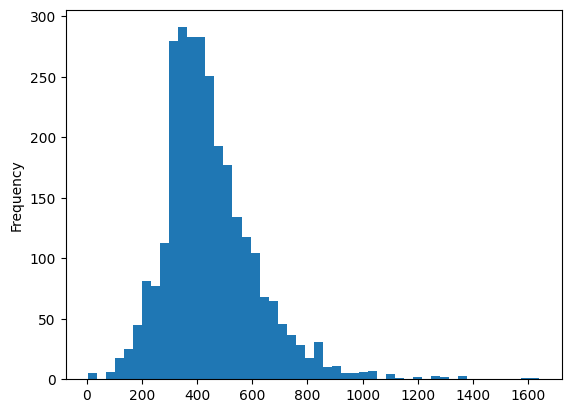

In [ ]:
messages['length'].plot.hist(bins=50)

In [ ]:
new_message['length'] = new_message['preprocessed_txt'].apply(len)

<Axes: ylabel='Frequency'>

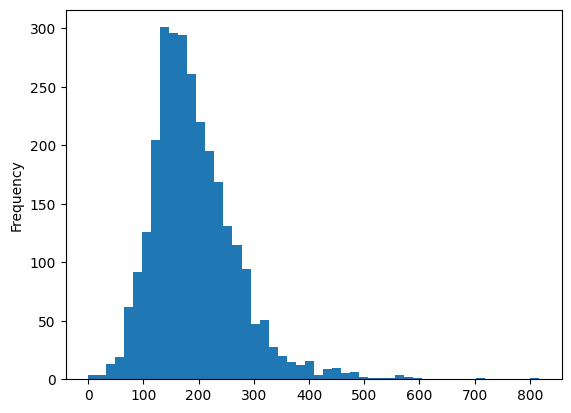

In [ ]:
new_message['length'].plot.hist(bins=50)

In [ ]:
from collections import Counter
def count_word_frequency(sentence):
    # Tokenize the sentence
    doc = nlp(sentence)

    # Count the frequency of each word using Counter
    word_freq = Counter([token.text for token in doc if not token.is_punct])

    return word_freq

sentence = """This is a sample sentence.
It demonstrates how to count the
frequency of words in a sentence."""
word_freq = count_word_frequency(sentence)
print(sentence)
for word, freq in word_freq.items():
    print(f"'{word}': {freq}")

This is a sample sentence. 
It demonstrates how to count the 
frequency of words in a sentence.
'This': 1
'is': 1
'a': 2
'sample': 1
'sentence': 2
'
': 2
'It': 1
'demonstrates': 1
'how': 1
'to': 1
'count': 1
'the': 1
'frequency': 1
'of': 1
'words': 1
'in': 1


# Spliting and training for creating model

In [ ]:
# split data to train and test, x is text, y is array,
#  CountVectorizer convert the text to matrix such as vector of word frequencies
#stratify is to create same number of category sample for test and train class
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer


X_train, X_test, y_train, y_test = train_test_split(
    # new_message.vectore.values,
    new_message.preprocessed_txt,
    new_message.detection,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=new_message.detection
)

# Model Using MultinomialNB

In [ ]:
from sklearn.naive_bayes import MultinomialNB

#1. create a pipeline object
#2. counter vectorizer is to split the sentence to 1 word 2 word 3 word based on the ngram_range
#3. used multinomialNB as classification
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),        #using the ngram_range parameter
    ('Multi NB', MultinomialNB())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   no stress       0.76      0.60      0.67       339
      stress       0.70      0.83      0.76       372

    accuracy                           0.72       711
   macro avg       0.73      0.71      0.71       711
weighted avg       0.73      0.72      0.72       711



In [ ]:
test_news = [
    "I am feeling very stressed lately because of my workload at work. I have been working long hours and feeling overwhelmed. On the bright side.",
    "The weather outside is lovely today. The birds are chirping, and the trees are swaying in the breeze. I'm looking forward to taking a walk in the park later.",
    "The sun is shining bright today, and the birds are singing happily in the trees. It's a beautiful day to take a walk in the park and enjoy nature's beauty. I feel calm and relaxed, and everything seems to be in perfect harmony. Life is good.",
    "We'd be saving so much money with this",
    "Despite the stress of daily life, I always make time for things that bring me joy. Whether it's a walk in the park or a phone call with a friend, taking a moment to unwind can make all the difference in reducing stress levels."
    "My heart is racing and I can't seem to catch my breath."
    "I can't seem to sleep at night because I'm so anxious."
]

text_predictions = clf.predict(test_news)

print(text_predictions)



['stress' 'no stress' 'no stress' 'stress' 'stress']


# Model Using BernoulliNB

In [ ]:
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()

#1. create a pipeline object
#2. counter vectorizer is to split the sentence to 1 word 2 word 3 word based on the ngram_range
#3. used BernoulliNB as classification
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),        #using the ngram_range parameter
    ('BernoulliNB', model)
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   no stress       0.76      0.63      0.68       339
      stress       0.71      0.82      0.76       372

    accuracy                           0.73       711
   macro avg       0.73      0.72      0.72       711
weighted avg       0.73      0.73      0.72       711



# Model Using SVM

In [ ]:
from sklearn.svm import SVC
SVM_model = SVC()

#1. create a pipeline object
#2. counter vectorizer is to split the sentence to 1 word 2 word 3 word based on the ngram_range
#3. used SVM as classification
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range = (1, 3))),        #using the ngram_range parameter
    ('SVM_model', SVM_model)
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   no stress       0.71      0.67      0.69       339
      stress       0.71      0.75      0.73       372

    accuracy                           0.71       711
   macro avg       0.71      0.71      0.71       711
weighted avg       0.71      0.71      0.71       711



# Model Using KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier



#1. create a pipeline object
#2. counter vectorizer is to split the sentence to 1 word 2 word 3 word based on the ngram_range
#3. used KNN as classification
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),        #using the ngram_range parameter
    ('KNN', (KNeighborsClassifier(n_neighbors=10, metric = 'euclidean')))
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   no stress       0.56      0.63      0.59       270
      stress       0.62      0.56      0.59       298

    accuracy                           0.59       568
   macro avg       0.59      0.59      0.59       568
weighted avg       0.59      0.59      0.59       568



# Model Using ForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier


#1. create a pipeline object
#2. counter vectorizer is to split the sentence to 1 word 2 word 3 word based on the ngram_range
#3. I used multinomialNB as classification
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range = (1, 3))),        #using the ngram_range parameter
    ('random_forest', RandomForestClassifier())
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   no stress       0.77      0.68      0.72       270
      stress       0.74      0.82      0.77       298

    accuracy                           0.75       568
   macro avg       0.75      0.75      0.75       568
weighted avg       0.75      0.75      0.75       568



# Model Using Word_Embedding

In [ ]:
# Attemp: using word embedding instead of countervectorizer

new_message['vectore'] = new_message['text'].apply(lambda text: nlp(text).vector)

In [ ]:
# split data to train and test, x is text, y is array,
#  CountVectorizer convert the text to matrix such as vector of word frequencies
#stratify is to create same number of category sample for test and train class
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer


X_train, X_test, y_train, y_test = train_test_split(
    new_message.vectore.values,
    # new_message.preprocessed_txt,
    new_message.detection,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=new_message.detection
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
# make vector being 2D matrix
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

# make vector value being positive
scaler = MinMaxScaler()
X_train1 = scaler.fit_transform(X_train_2d)
X_test1 = scaler.fit_transform(X_test_2d)


In [ ]:
from  sklearn.neighbors import KNeighborsClassifier

#1. creating a KNN model object
clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')

#2. fit with all_train_embeddings and y_train
clf.fit(X_train_2d, y_train)

#3. get the predictions for all_test_embeddings and store it in y_pred
y_pred = clf.predict(X_test_2d)

#4. print the classfication report
print(classification_report(y_test, y_pred))

NameError: ignored

In [ ]:
from ipywidgets import Label, VBox, HBox, Text, Button, Output, HTML
import base64
import random
import cv2 as cv

# Define the title and image path
title_text = "Stress Detector"
image_path = "stress.png"

# Read the image file and encode it as base64
with open(image_path, "rb") as f:
    image_data = f.read()
    encoded_image = base64.b64encode(image_data).decode()

# Create an HTML widget to display the title and image
title_html = HTML(f"<h1>{title_text}</h1><img src='data:image/png;base64,{encoded_image}'/>")

# Create the message box, output box, and button
message_box = Text(placeholder='Type the message here')
output_box = Output()
detect_button = Button(description='Detect Stress')


# # this may change if we pick a different model
# def detect_stress(message):
#     data = cv.transform([message]).toarray()
#     output = model.predict(data)
#     stress_res = output[0]
#     if stress_res == 'stress':
#         return 'stress'
#     else:
#         return 'no stress'

# Create a label for the output box
output_label = Label(value='Result:')

phrases = ['“There are times when we stop, we sit still. We listen and breezes from a whole other world begin to whisper.” —James Carroll.', '“Breath is the power behind all things…. I breathe in and know that good things will happen.” —Tao Porchon-Lynch',
          'Within you, there is a stillness and a sanctuary to which you can retreat at any time and be yourself.” —Hermann Hesse', '“Feelings come and go like clouds in a windy sky. Conscious breathing is my anchor.” —Thích Nhất Hạnh', '“Calmness is the cradle of power.” —Josiah Gilbert Holland',
          '“Simply let experience take place very freely, so that your open heart is suffused with the tenderness of true compassion.” —Tsoknyi Rinpoche', '“Don’t try to force anything. Let life be a deep let-go. God opens millions of flowers every day without forcing their buds.” —Osho',
          '“Understand this and be free: we are not in our bodies; our bodies are inside us.” —Sean A. Mulvihill', '“Set peace of mind as your highest goal, and organize your life around it.” —Brian Tracy',
          '“Many a calm river begins as a turbulent waterfall, yet none hurtles and foams all the way to the sea.” —Mikhail Lermontov',
          '“Doing something that is productive is a great way to alleviate emotional stress. Get your mind doing something that is productive.” —Ziggy Marley', '“Rule number one is, don’t sweat the small stuff. Rule number two is, it’s all small stuff.” —Robert Eliot',
          '“Give your stress wings and let it fly away.” —Terri Guillemets', '“The greatest weapon against stress is our ability to choose one thought over another.” —William James', '“The day she let go of the things that were weighing her down, was the day she began to shine the brightest.” —Katrina Mayer',
          '“In the woods, we return to reason and faith. There I feel that nothing can befall me in life—no disgrace, no calamity (leaving me my eyes), which nature cannot repair.” —Ralph Waldo Emerson',
          '“Breathe. Let go. And remind yourself that this very moment is the only one you know you have for sure.” —Oprah Winfrey', '“The more tranquil a man becomes, the greater is his success, his influence, his power for good. Calmness of mind is one of the beautiful jewels of wisdom.” —James Allen',
          '“When you realize how perfect everything is you will tilt your head back and laugh at the sky.” —Buddha']

# Define the function to be called when the button is clicked
def on_button_click(b):
    message = message_box.value
    message_box.value = ""
    # message_embedding = np.array(embedding_function(message)).reshape(1, -1)
    stress_res = clf.predict([message])
    with output_box:
        output_box.clear_output()
        if stress_res == 'stress':
            print(f'{stress_res}')
            print(random.choice(phrases))
        else:
            print(f'{stress_res}')

# Create a clear button to clear the output
clear_button = Button(description='Clear Output')

# Adding colors to the buttons
detect_button.style.button_color = 'green'
clear_button.style.button_color = 'red'


def on_clear_button_click(b):
    with output_box:
        output_box.clear_output()

clear_button.on_click(on_clear_button_click)

# Position the message box, output box, and button vertically
input_widgets = VBox([Label('Message:'), message_box])
output_widgets = VBox([output_label, output_box, clear_button])
button_widgets = VBox([detect_button])
all_widgets = HBox([input_widgets, output_widgets, button_widgets])

# Attach the button click function to the button
detect_button.on_click(on_button_click)

# Combine the title and widgets into a single VBox
gui_widgets = VBox([title_html, all_widgets])

# Display the widgets
display(gui_widgets)

# Quotes: https://www.success.com/19-calming-quotes-to-help-you-stress-less/

In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8000)"))

https://zclhvr1zmwq-496ff2e9c6d22116-8000-colab.googleusercontent.com/


In [ ]:
import webbrowser
from flask import Flask, render_template, request
import random
app = Flask(__name__,template_folder = '/content/')

@app.route("/")
def home():
    return render_template("template.html")
@app.route("/detect_stress", methods=['POST'])
def detect_stress():
  phrases = ['“There are times when we stop, we sit still. We listen and breezes from a whole other world begin to whisper.” —James Carroll.', '“Breath is the power behind all things…. I breathe in and know that good things will happen.” —Tao Porchon-Lynch',
          'Within you, there is a stillness and a sanctuary to which you can retreat at any time and be yourself.” —Hermann Hesse', '“Feelings come and go like clouds in a windy sky. Conscious breathing is my anchor.” —Thích Nhất Hạnh', '“Calmness is the cradle of power.” —Josiah Gilbert Holland',
          '“Simply let experience take place very freely, so that your open heart is suffused with the tenderness of true compassion.” —Tsoknyi Rinpoche', '“Don’t try to force anything. Let life be a deep let-go. God opens millions of flowers every day without forcing their buds.” —Osho',
          '“Understand this and be free: we are not in our bodies; our bodies are inside us.” —Sean A. Mulvihill', '“Set peace of mind as your highest goal, and organize your life around it.” —Brian Tracy',
          '“Many a calm river begins as a turbulent waterfall, yet none hurtles and foams all the way to the sea.” —Mikhail Lermontov',
          '“Doing something that is productive is a great way to alleviate emotional stress. Get your mind doing something that is productive.” —Ziggy Marley', '“Rule number one is, don’t sweat the small stuff. Rule number two is, it’s all small stuff.” —Robert Eliot',
          '“Give your stress wings and let it fly away.” —Terri Guillemets', '“The greatest weapon against stress is our ability to choose one thought over another.” —William James', '“The day she let go of the things that were weighing her down, was the day she began to shine the brightest.” —Katrina Mayer',
          '“In the woods, we return to reason and faith. There I feel that nothing can befall me in life—no disgrace, no calamity (leaving me my eyes), which nature cannot repair.” —Ralph Waldo Emerson',
          '“Breathe. Let go. And remind yourself that this very moment is the only one you know you have for sure.” —Oprah Winfrey', '“The more tranquil a man becomes, the greater is his success, his influence, his power for good. Calmness of mind is one of the beautiful jewels of wisdom.” —James Allen',
          '“When you realize how perfect everything is you will tilt your head back and laugh at the sky.” —Buddha']

  message = request.form['message']
  stress_res = clf.predict([message])
  if stress_res == 'stress':
      return f"Results: You are stressed. <br> {random.choice(phrases)}"
  else:
      return f"Results: You are not stressed!"

if __name__ == "__main__":
    app.run(port=8000)


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8000
INFO:werkzeug:Press CTRL+C to quit
